This notebook requires that the constraint and the numb_sites_region are run before

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

motif_length = 3

# Trinucleotide model

In [52]:
Constraint = pd.read_csv("output_data/trinuc_constraint_mean_sem.csv")
numb_sites = pd.read_csv("output_data/length_perregion.csv")
Mut_rates = pd.read_csv("output_data/average_mutrates_motiflength" + str(motif_length) + "_mean_sem.csv")

In [53]:
Constraint = Constraint[Constraint.iloc[:, 0] == "mean"].reset_index(drop=True)
Constraint = Constraint.iloc[:, 1:3].copy()
Constraint.columns = ["Region", "Constraint"]
Constraint

,Region,Constraint
0,cds,0.618501
1,distalIG,-0.020690
2,introns3UTR,0.378383
3,introns5UTR,0.373675
4,intronsAR,0.133234
5,introns_nonUTR,0.203996
6,proximal3IG,0.056705
7,proximal5IG,0.050106


In [54]:
numb_sites = numb_sites.iloc[:, 1:4].copy()
numb_sites


,Region,total_numb_sites,fraction_of_total_sites
0,cds,32311749,0.011633
1,distalIG,548608197,0.197507
2,introns3UTR,6675828,0.002403
3,introns5UTR,6709323,0.002415
4,intronsAR,1340744649,0.482687
5,introns_nonUTR,635749401,0.228879
6,proximal3IG,103451304,0.037244
7,proximal5IG,103420896,0.037233


In [55]:
Mut_rates = Mut_rates[Mut_rates.iloc[:, 0] == "mean"].reset_index(drop=True)
Mut_rates = Mut_rates.iloc[:, 1:3].copy()
Mut_rates.columns = ["Region", "Mut_rates"]
Mut_rates

,Region,Mut_rates
0,cds,1.863071e-08
1,distalIG,1.291262e-08
2,introns3UTR,1.756165e-08
3,introns5UTR,1.740631e-08
4,intronsAR,1.377059e-08
5,introns_nonUTR,1.342659e-08
6,proximal3IG,1.388788e-08
7,proximal5IG,1.389671e-08


In [56]:
sum(numb_sites["total_numb_sites"])

2777671347

Check visually that the two tables above have the same order of rows.

In [57]:
Udregion = (
    Constraint["Constraint"]
    * 2 * numb_sites["total_numb_sites"]
    * Mut_rates["Mut_rates"]
).clip(lower=0)

Udregion

0    0.744664
1    0.000000
2    0.088722
3    0.087279
4    4.919763
5    3.482595
6    0.162939
7    0.144027
dtype: float64

In [58]:
fraction_region_df = pd.DataFrame({
    "Region": Constraint["Region"],
    "numb_sites":  numb_sites["total_numb_sites"] / sum(numb_sites["total_numb_sites"]),
    "Constraint": Constraint["Constraint"] / sum(Constraint["Constraint"]),
    "AverageMutRate": Mut_rates["Mut_rates"] / sum(Mut_rates["Mut_rates"]),
    "Udregion": Udregion.values / Udregion.values.sum()
})

order = ["cds", "introns_nonUTR", "introns3UTR", "introns5UTR", "intronsAR", "proximal5IG", "proximal3IG", "distalIG"]

fraction_region_df["Region"] = pd.Categorical(
    fraction_region_df["Region"],
    categories=order,
    ordered=True
)

fraction_region_df = fraction_region_df.sort_values("Region")
fraction_region_df

,Region,numb_sites,Constraint,AverageMutRate,Udregion
0,cds,0.011633,0.344778,0.153348,0.077328
5,introns_nonUTR,0.228879,0.113716,0.110513,0.361641
2,introns3UTR,0.002403,0.210927,0.144549,0.009213
3,introns5UTR,0.002415,0.208302,0.143270,0.009063
4,intronsAR,0.482687,0.074270,0.113345,0.510879
7,proximal5IG,0.037233,0.027931,0.114383,0.014956
6,proximal3IG,0.037244,0.031610,0.114310,0.016920
1,distalIG,0.197507,-0.011534,0.106283,0.000000


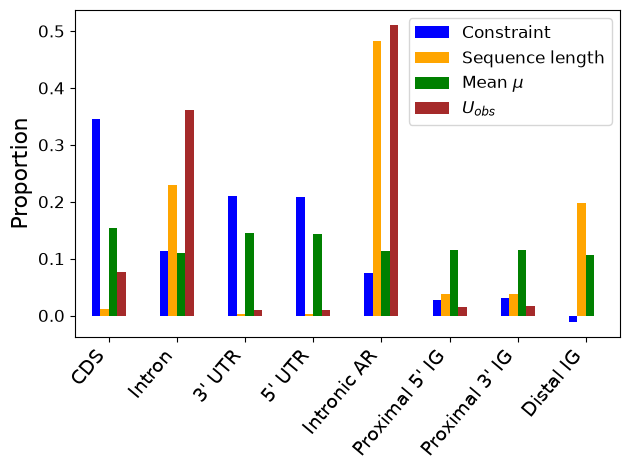

In [59]:
ax = fraction_region_df.plot(
    x='Region',
    y=['Constraint', 'numb_sites', 'AverageMutRate', 'Udregion'],
    kind='bar',
    color=['blue', 'orange', 'green', 'brown']
#    order=["cds", "introns", "intronsAR", "3UTR", "5UTR", "distalIG", "proximal5IG", "proximal3IG"]
)
plt.ylabel('Proportion', fontsize=16)
plt.yticks(fontsize=12)
ax.set_xticklabels(["CDS", "Intron", "3' UTR", "5' UTR", "Intronic AR", "Proximal 5' IG", "Proximal 3' IG", "Distal IG"], rotation=50, ha='right', fontsize=14)
plt.legend(['Constraint', 'Sequence length', r'Mean $\mu$', r'$U_{obs}$'], fontsize=12)
plt.xlabel('')
plt.tight_layout()

In [60]:
Ud = Udregion.values.sum()
Ud

np.float64(9.629988585538843)